# 1. EDA

In [ ]:
import pandas as pd
from pathlib import Path
import os

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

import cv2

In [ ]:
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'

data = []
for split in os.listdir(RAW_DATA_DIR):
    for emotion_dir in os.listdir(RAW_DATA_DIR / split):
        for img in os.listdir(RAW_DATA_DIR / split / emotion_dir):
            data.append({
                'image': img,
                'emotion': emotion_dir,
                'split': split,
            })

df = pd.DataFrame(data)

In [19]:
df

,image,emotion,split
0,Training_80936636.jpg,angry,train
1,Training_36791054.jpg,angry,train
2,Training_30410150.jpg,angry,train
3,Training_57899228.jpg,angry,train
4,Training_44272003.jpg,angry,train
...,...,...,...
35882,PrivateTest_23296080.jpg,neutral,test
35883,PrivateTest_32421186.jpg,neutral,test
35884,PrivateTest_33205539.jpg,neutral,test
35885,PublicTest_1492943.jpg,neutral,test


In [38]:
df['split'].value_counts()

split
train    28709
test      7178
Name: count, dtype: int64

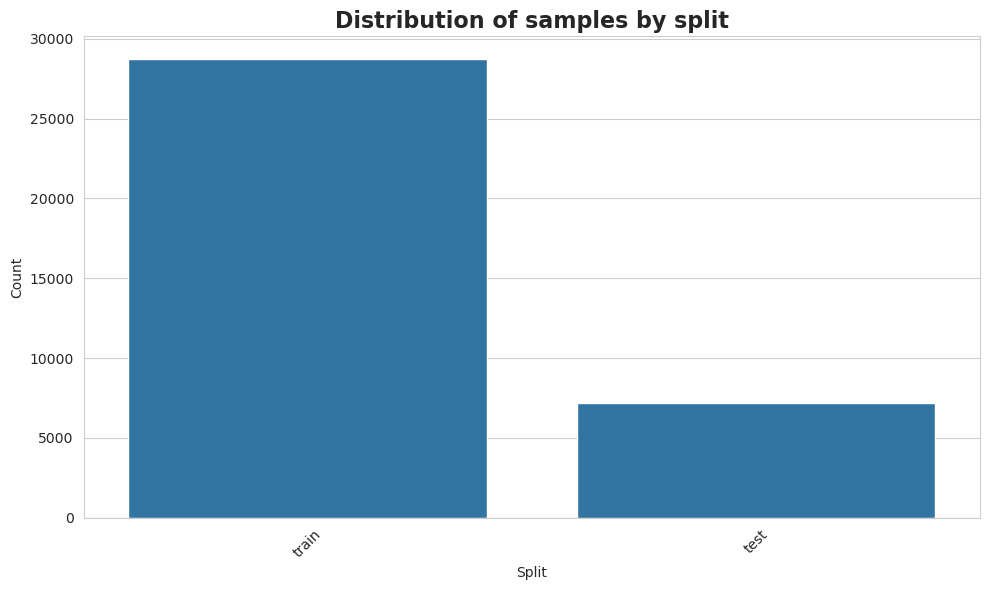

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(
    data=df,
    x='split',
    ax=ax
)

ax.set_title('Distribution of samples by split', fontsize=16, fontweight='bold')
ax.set_xlabel('Split', fontsize=10)
ax.set_ylabel('Count', fontsize=10)

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [39]:
df.groupby('split')['emotion'].value_counts()

split  emotion 
test   happy       1774
       sad         1247
       neutral     1233
       fear        1024
       angry        958
       surprise     831
       disgust      111
train  happy       7215
       neutral     4965
       sad         4830
       fear        4097
       angry       3995
       surprise    3171
       disgust      436
Name: count, dtype: int64

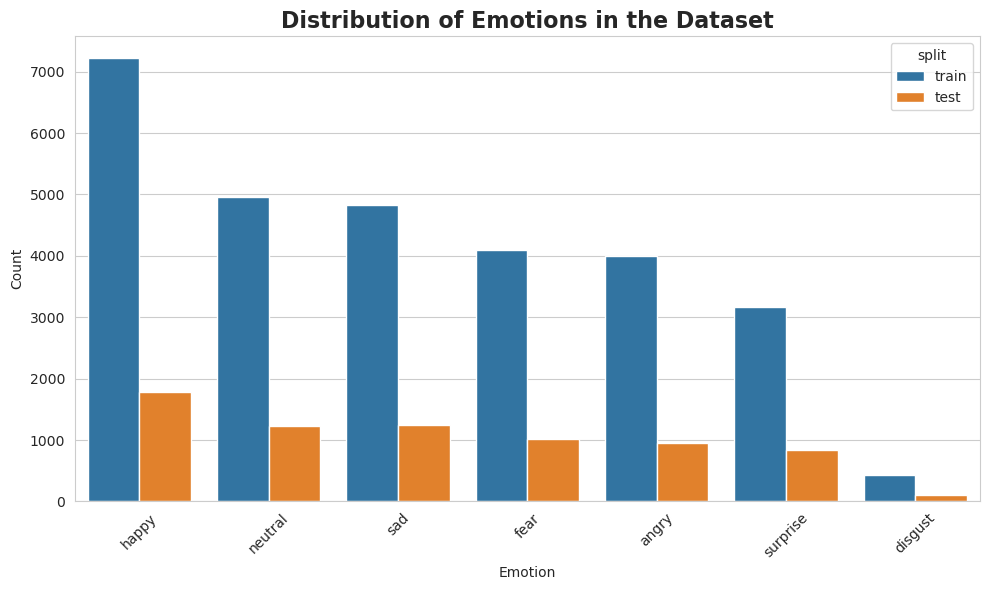

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(
    data=df,
    x='emotion',
    order=df['emotion'].value_counts().index,
    hue='split',
    ax=ax
)

ax.set_title('Distribution of Emotions in the Dataset', fontsize=16, fontweight='bold')
ax.set_xlabel('Emotion', fontsize=10)
ax.set_ylabel('Count', fontsize=10)

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [34]:
def plot_images_sample(df):
    """
    Plot an image per emotion from train set
    """
    fig, axes = plt.subplots(1, 7, figsize=(20, 5))
    emotions = df['emotion'].unique()

    for i, emotion in enumerate(emotions):
        img_path = RAW_DATA_DIR / 'train' / emotion / df[df['emotion'] == emotion]['image'].iloc[0]
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(emotion)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

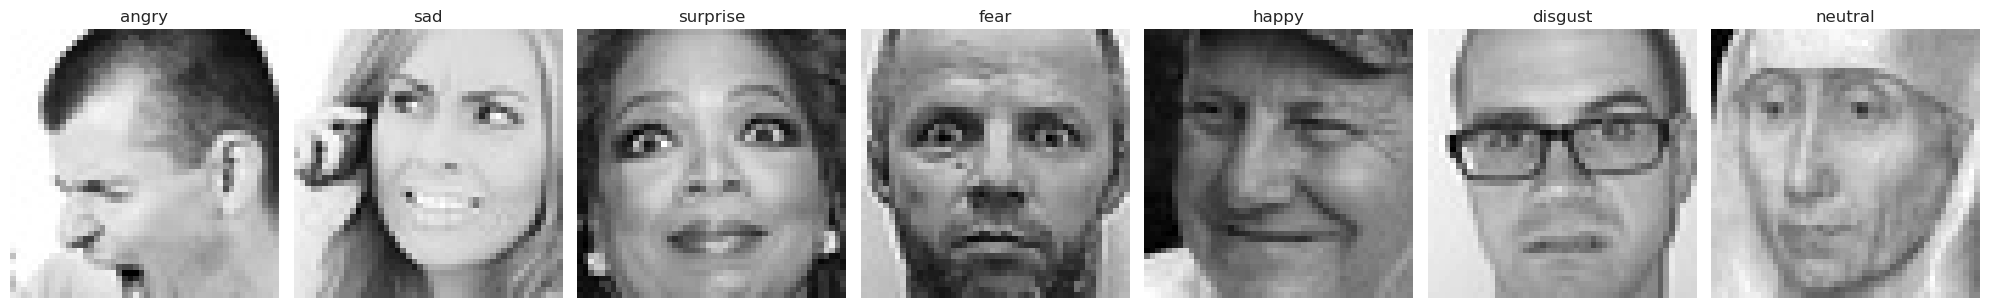

In [35]:
plot_images_sample(df)